C:\Users\Sudhir Kulaye\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning:

Unknown extension is not supported and will be removed

C:\Users\Sudhir Kulaye\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning:

Conditional Formatting extension is not supported and will be removed



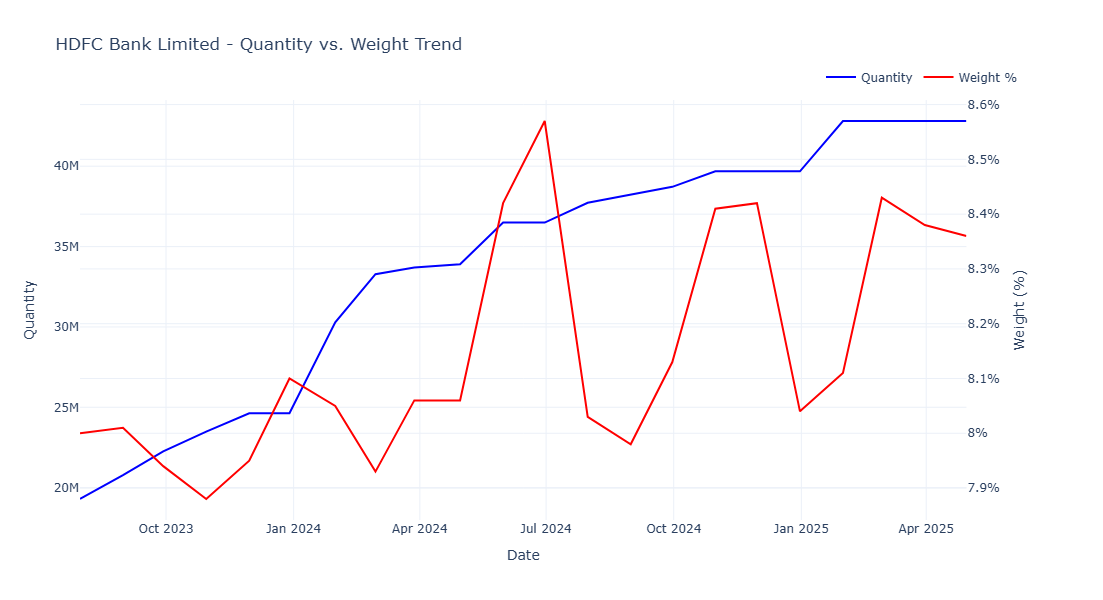

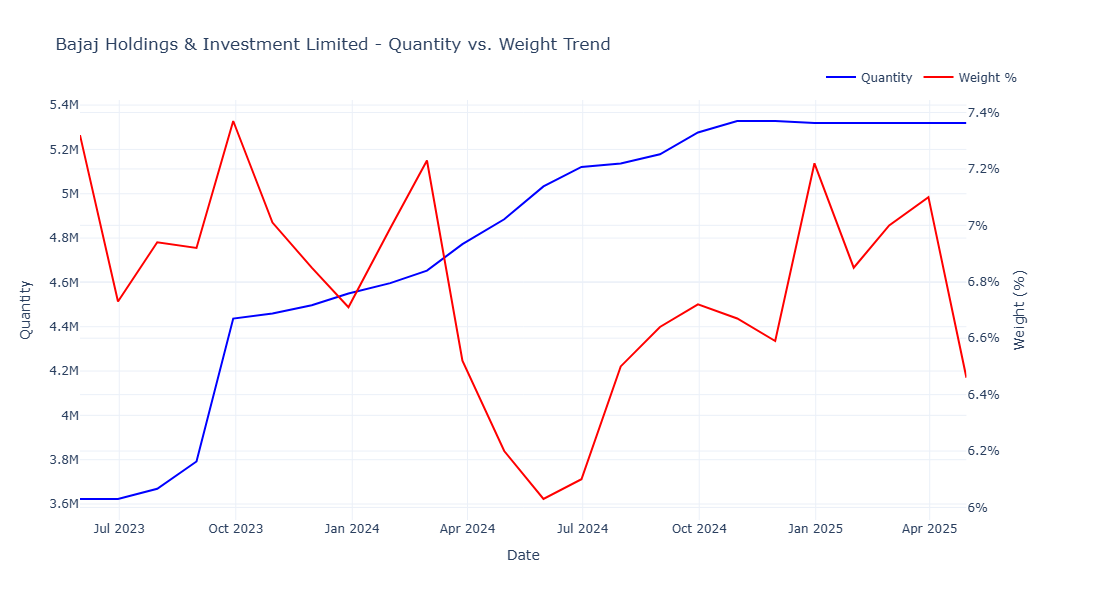

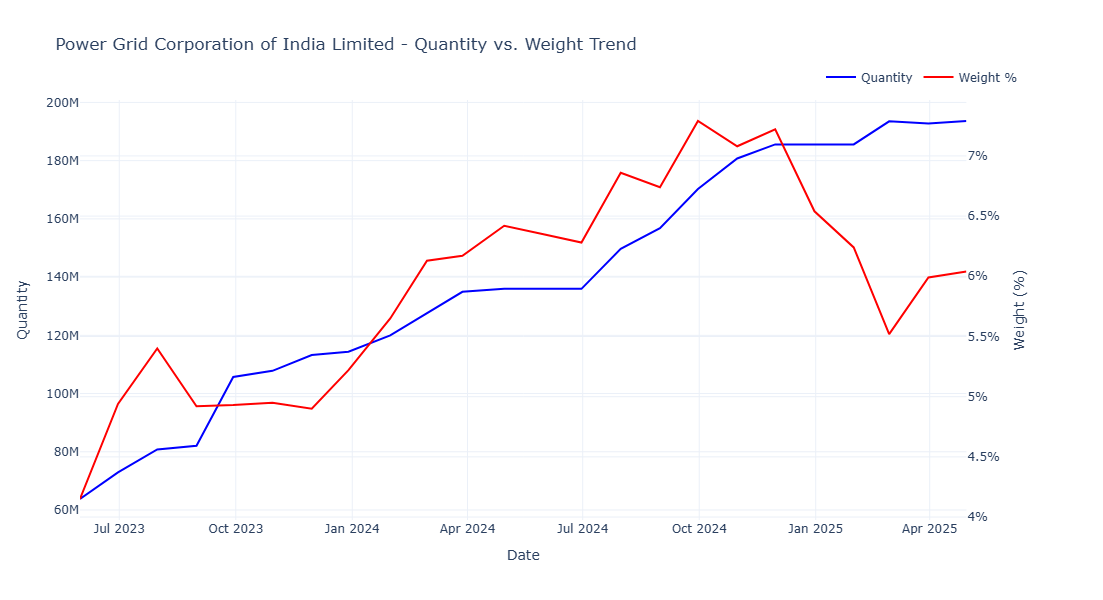

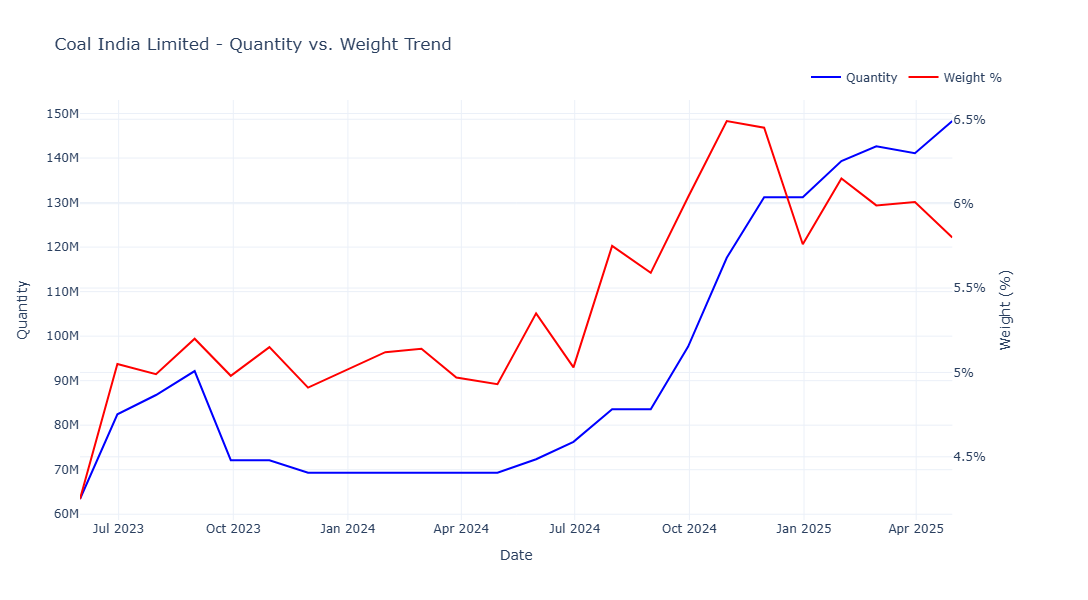

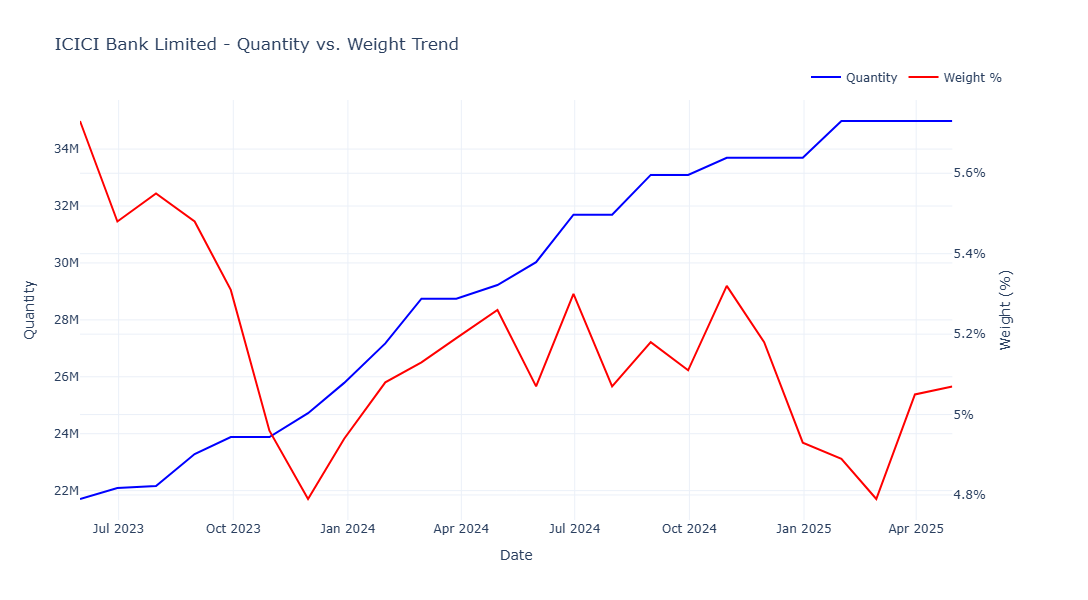

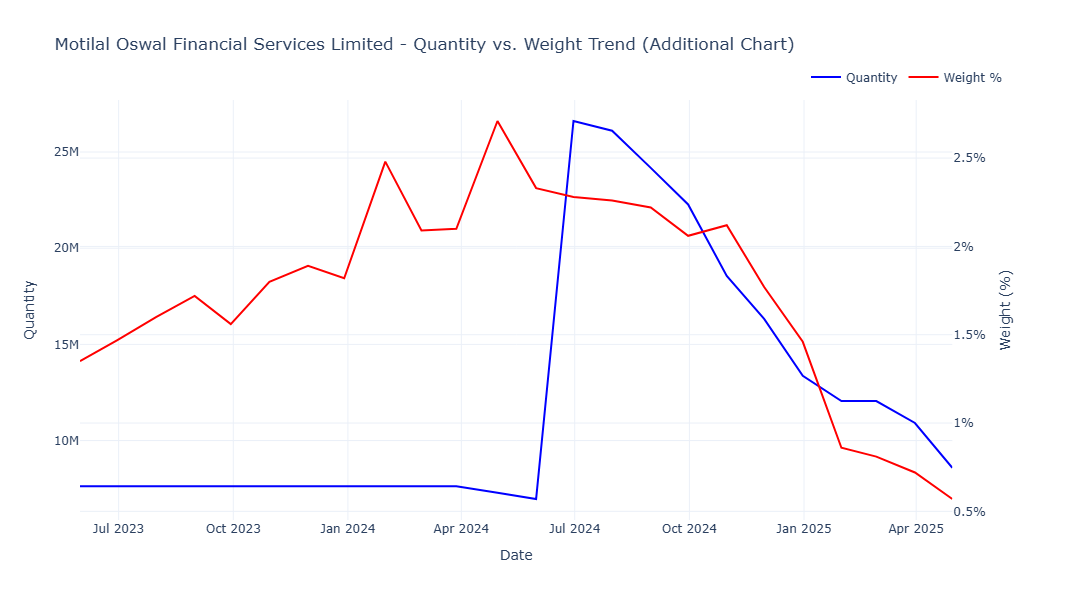

In [15]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime

# Configuration
file_path = r"C:\MyDocuments\03Business\06ClientData\AmbitCoffeeCanPMS\PMSHoldingHistory.xlsx"
sheet_name = "ParagParikhFlexiCap"
header_row = 2  # 1-based index
specific_stock = "Motilal Oswal Financial Services Limited"
# "Indian Energy Exchange Limited"  # Default stock for the additional chart

# Read the Excel file
df = pd.read_excel(file_path, sheet_name=sheet_name, header=header_row-1)

# Clean column names (remove extra spaces, special characters)
df.columns = df.columns.str.strip()

# Convert date column to datetime if it's not already
df['Date'] = pd.to_datetime(df['Date'])

# Get the latest date in the dataset
latest_date = df['Date'].max()

# Get the top 5 stocks by weight on the latest date
latest_holdings = df[df['Date'] == latest_date]
top_5_stocks = latest_holdings.sort_values('%Wt.', ascending=False).head(5)['Stock'].tolist()

# Create a list of all stocks to plot (top 5 + specific stock)
stocks_to_plot = top_5_stocks.copy()
if specific_stock not in stocks_to_plot:
    stocks_to_plot.append(specific_stock)

# Create individual plots for each stock
for stock in stocks_to_plot:
    stock_data = df[df['Stock'] == stock].sort_values('Date')
    
    # Create figure with secondary y-axis
    fig = make_subplots(specs=[[{"secondary_y": True}]])
    
    # Add Qt. trace (primary y-axis)
    fig.add_trace(
        go.Scatter(
            x=stock_data['Date'],
            y=stock_data['Qt.'],
            name="Quantity",
            line=dict(color='blue'),
            hovertemplate="Date: %{x|%d %b %Y}<br>Quantity: %{y:,}<extra></extra>"
        ),
        secondary_y=False,
    )
    
    # Add %Wt. trace (secondary y-axis)
    # Multiply by 100 to convert from decimal to percentage for display
    fig.add_trace(
        go.Scatter(
            x=stock_data['Date'],
            y=stock_data['%Wt.']*100,  # Convert to percentage
            name="Weight %",
            line=dict(color='red'),
            hovertemplate="Date: %{x|%d %b %Y}<br>Weight %: %{y:.2f}%<extra></extra>"
        ),
        secondary_y=True,
    )
    
    # Update layout
    title = f"{stock} - Quantity vs. Weight Trend"
    if stock == specific_stock and stock not in top_5_stocks:
        title += " (Additional Chart)"
    
    fig.update_layout(
        title=title,
        xaxis_title="Date",
        hovermode="x unified",
        template="plotly_white",
        height=600,
        xaxis=dict(
            tickformat="%b %Y",
            tickmode="auto",
            dtick="M3"
        ),
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        )
    )
    
    # Set y-axes titles
    fig.update_yaxes(title_text="Quantity", secondary_y=False)
    fig.update_yaxes(title_text="Weight (%)", secondary_y=True)
    
    # Format the percentage axis to show proper % values
    fig.update_yaxes(
        ticksuffix="%",
        secondary_y=True
    )
    
    # Show the figure
    fig.show()